# Proyek Analisis Data: E-Commerce Public Dataset
Dataset yang digunakan adalah Brazilian E-Commerce Dataset dari Olist yang berisi data transaksi pelanggan, order, produk, pembayaran, dan wilayah pelanggan. Dataset ini digunakan untuk menganalisis tren penjualan dan segmentasi pelanggan untuk mendukung pengambilan keputusan bisnis.

- **Nama:** [Kurnia Irianti]
- **Email Dicoding:** [kurniairianti21@gmail.com]
- **ID Dicoding:** [cdcc228]

## Menentukan Pertanyaan Bisnis

Sebelum memulai analisis, kita perlu mendefinisikan pertanyaan bisnis yang ingin dijawab. Pertanyaan yang efektif harus spesifik, terukur, dan relevan dengan data yang tersedia.

**Pertanyaan Bisnis:**
1. Kategori produk apa yang paling banyak terjual dan bagaimana tren penjualannya selama periode 2016-2018?
2. Negara bagian mana di Brasil yang memiliki jumlah order terbanyak selama periode 2016-2018?
3. Bagaimana segmentasi pelanggan berdasarkan perilaku pembelian mereka selama periode 2016-2018 menggunakan RFM Analysis?




Analisis dilakukan untuk menjawab beberapa pertanyaan bisnis berikut agar perusahaan dapat memahami pola penjualan dan pelanggan.

## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Library berhasil diimport!')

Library berhasil diimport!


## Data Wrangling

### Gathering Data

Dataset yang digunakan adalah **Brazilian E-Commerce Public Dataset by Olist** yang tersedia di Kaggle. Dataset ini terdiri dari beberapa file CSV yang saling terhubung, mencakup informasi tentang orders, customers, products, sellers, payments, reviews, dan geolocation.

**Sumber data:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


Dataset berhasil dimuat dari beberapa file CSV yang terdiri dari order, customer, product, dan payment. Data ini akan digabungkan untuk dianalisis lebih lanjut.

In [2]:
# Load semua datase
customers_df          = pd.read_csv('olist_customers_dataset.csv')
orders_df             = pd.read_csv('olist_orders_dataset.csv')
order_items_df        = pd.read_csv('olist_order_items_dataset.csv')
order_payments_df     = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews_df      = pd.read_csv('olist_order_reviews_dataset.csv')
products_df           = pd.read_csv('olist_products_dataset.csv')
sellers_df            = pd.read_csv('olist_sellers_dataset.csv')
geolocation_df        = pd.read_csv('olist_geolocation_dataset.csv')
category_translation_df = pd.read_csv('product_category_name_translation.csv')

### Assessing Data

Pada tahap ini, kita akan memeriksa kualitas data: missing values, tipe data, dan duplikasi.

Proses assessing dilakukan untuk memastikan kualitas data sebelum dilakukan analisis sehingga hasil analisis lebih akurat.

In [3]:
def assess_dataframe(df, name):
    print(f"{'='*50}")
    print(f"Dataset: {name}")
    print(f"Shape: {df.shape}")
    print(f"\nInfo:")
    print(df.dtypes)
    print(f"\nMissing values:")
    missing = df.isnull().sum()
    print(missing[missing > 0] if missing.any() else "  Tidak ada missing values")
    print(f"\nDuplikasi: {df.duplicated().sum()} baris")

for name, df in [('orders', orders_df), ('order_items', order_items_df),
                  ('products', products_df), ('customers', customers_df)]:
    assess_dataframe(df, name)

Dataset: orders
Shape: (99441, 8)

Info:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Missing values:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Duplikasi: 0 baris
Dataset: order_items
Shape: (112650, 7)

Info:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

Missing values:
  Tidak ada missing values

Duplikasi: 0 baris
Dataset: products
Shape: (32951, 9)

Info:
product_id                     object
product_category_name          object


**Insight Assessing Data:**
- Dataset `orders` memiliki beberapa missing values pada kolom tanggal pengiriman, yang wajar karena beberapa order mungkin dibatalkan atau belum dikirim.
- Dataset `products` memiliki missing values pada kolom deskripsi dan nama kategori.
- Tidak ditemukan duplikasi pada dataset utama.
- Kolom tanggal masih bertipe object, perlu dikonversi ke datetime.
-  Ditemukan beberapa missing value pada kolom tertentu seperti review dan payment. Selain itu terdapat perbedaan tipe data pada kolom tanggal sehingga perlu dilakukan cleaning data.

### Cleaning Data

Berdasarkan hasil assessment, kita akan melakukan pembersihan data meliputi: konversi tipe data, penanganan missing values, dan penggabungan dataset.


Proses cleaning ini memastikan data siap digunakan untuk analisis tren penjualan dan segmentasi pelanggan tanpa adanya error pada tipe data atau missing values.

In [4]:
# 1. Konversi kolom tanggal ke datetime
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# 2. Filter hanya order yang sudah delivered
orders_delivered = orders_df[orders_df['order_status'] == 'delivered'].copy()
print(f'Order delivered: {len(orders_delivered):,} dari {len(orders_df):,} total order')

# 3. Tambahkan kolom waktu
orders_delivered['order_year']      = orders_delivered['order_purchase_timestamp'].dt.year
orders_delivered['order_month']     = orders_delivered['order_purchase_timestamp'].dt.month
orders_delivered['order_yearmonth'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')

# 4. Gabungkan produk dengan terjemahan kategori
products_df = products_df.merge(category_translation_df, on='product_category_name', how='left')
products_df['product_category_name_english'].fillna('unknown', inplace=True)

# 5. Buat master dataframe gabungan
master_df = (
    orders_delivered
    .merge(order_items_df, on='order_id', how='inner')
    .merge(order_payments_df.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id', how='left')
    .merge(customers_df[['customer_id','customer_city','customer_state']], on='customer_id', how='left')
    .merge(products_df[['product_id','product_category_name_english']], on='product_id', how='left')
)

print(f'Master dataframe: {master_df.shape}')
master_df.head()

Order delivered: 96,478 dari 99,441 total order
Master dataframe: (110197, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,...,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_value,customer_city,customer_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,sao paulo,SP,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46,barreiras,BA,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12,vianopolis,GO,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,...,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20,sao goncalo do amarante,RN,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,...,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62,santo andre,SP,stationery


**Insight Cleaning Data:**
- Dari total order, sekitar 96% berstatus `delivered` — ini yang akan menjadi fokus analisis karena merepresentasikan transaksi yang benar-benar selesai.
- Penggabungan dataset menghasilkan master dataframe yang siap untuk analisis lebih lanjut.
- Kolom tanggal telah dikonversi sehingga analisis tren waktu bisa dilakukan.

## Exploratory Data Analysis (EDA)

EDA dilakukan untuk mengeksplorasi karakteristik setiap dataset sebelum masuk ke tahap analisis mendalam. Tahap ini bukan untuk menjawab pertanyaan bisnis secara langsung, melainkan untuk memahami distribusi, pola, dan hubungan antar variabel dalam data.


### Explore orders_df

Dataset ini memuat informasi transaksi order yang sudah berstatus *delivered*, termasuk waktu pembelian, nilai pembayaran, dan informasi pelanggan.


In [5]:
orders_delivered.sample(5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,order_yearmonth
32568,541c844f36e4b57a49d0baa723855958,78cc60e3f5c4141e0011e83edcfc9702,delivered,2018-05-08 16:04:36,2018-05-08 16:31:41,2018-05-09 10:36:00,2018-05-10 18:48:49,2018-05-16,2018,5,2018-05
29381,5764b52361ed5b661d24dff30c8c3625,ff45a8aaeebad334186dbfd659168d65,delivered,2018-01-16 14:33:54,2018-01-16 14:51:35,2018-01-23 22:25:55,2018-01-26 00:53:30,2018-01-31,2018,1,2018-01
85323,cc852cf36cf64a124456f5f10b2142ae,986be13e0019c9cafc514e4773ffbec0,delivered,2018-01-11 15:17:23,2018-01-11 15:28:32,2018-01-16 20:52:33,2018-01-17 16:29:13,2018-01-26,2018,1,2018-01
40597,9cca241ed87f1ae14fc65df5c12397a8,8e89d5cccc3988179197d9b18ae3292a,delivered,2017-10-29 03:10:28,2017-10-29 03:25:46,2017-10-30 17:14:13,2017-11-16 21:21:39,2017-11-29,2017,10,2017-10
38700,5b8b4d4819cdb1edb181f172f6cf9a2c,c1d8da410642f2db087557428519b6e4,delivered,2018-01-19 20:27:23,2018-01-20 20:40:18,2018-01-22 17:34:06,2018-02-05 23:06:35,2018-02-16,2018,1,2018-01


In [6]:
# Rangkuman statistik deskriptif orders_delivered
orders_delivered.describe(include='all')


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,order_yearmonth
count,96478,96478,96478,96478,96464,96476,96470,96478,96478.000000,96478.000000,96478
unique,96478,96478,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-11
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7289
mean,NaN,NaN,NaN,2018-01-01 23:29:31.939913984,2018-01-02 10:53:23.338012160,2018-01-05 05:01:50.912330240,2018-01-14 12:41:33.581683456,2018-01-25 17:09:52.325711616,2017.544331,6.031116,NaN
min,NaN,NaN,NaN,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,2016.000000,1.000000,NaN
25%,NaN,NaN,NaN,2017-09-14 09:00:23.249999872,2017-09-14 14:48:54,2017-09-18 16:46:13.249999872,2017-09-25 22:15:09.500000,2017-10-05 00:00:00,2017.000000,3.000000,NaN
50%,NaN,NaN,NaN,2018-01-20 19:45:45,2018-01-22 13:50:04,2018-01-24 16:13:47.500000,2018-02-02 19:32:21,2018-02-16 00:00:00,2018.000000,6.000000,NaN
75%,NaN,NaN,NaN,2018-05-05 18:54:47,2018-05-06 10:57:24.750000128,2018-05-08 14:35:00,2018-05-15 22:54:48.500000,2018-05-28 00:00:00,2018.000000,8.000000,NaN
max,NaN,NaN,NaN,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,2018.000000,12.000000,NaN


**Insight:**
- Dataset mencakup order dari tahun 2016 hingga 2018 dengan total ribuan transaksi.
- Kolom tanggal sudah berhasil dikonversi ke tipe datetime sehingga siap untuk analisis tren waktu.
- Sekitar 96% dari total order berstatus *delivered* — ini yang menjadi fokus analisis.


### Explore customers_df

Dataset ini memuat informasi demografi pelanggan, termasuk kota dan negara bagian tempat tinggal.


In [7]:
customers_df.sample(5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
86611,33d8e7921924c3b75975500363ac32ed,09a2a3befff4ee3680617f07d9b473ed,29147,cariacica,ES
98455,b35b1cf12fb166b4764e0962bc87ab18,7dd2e8827e0bb9c6e63127eafc85d9e3,35540,oliveira,MG
24143,2f35662765ac3645bd3bfcc100a7eedc,3f1a25a478961e0e1a1e777026236dc8,8110,sao paulo,SP
46103,b56e91c06de67f577c3764c24dac0756,d0362502da3b59199ec21fe40b325f1d,74140,goiania,GO
28362,11c897fd95b346aa239cb2b6401e73f3,d28cc8ac5e1e6dfb3d1f0b6f107430ae,36974,durande,MG


In [8]:
# Rangkuman statistik deskriptif customers_df
customers_df.describe(include='all')


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [9]:
# Persebaran pelanggan berdasarkan negara bagian
customers_df.groupby(by='customer_state').customer_id.nunique().sort_values(ascending=False)


,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


In [10]:
# Persebaran pelanggan berdasarkan kota (top 10)
customers_df.groupby(by='customer_city').customer_id.nunique().sort_values(ascending=False).head(10)


,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
campinas,1444
porto alegre,1379
salvador,1245
guarulhos,1189


**Insight:**
- Pelanggan tersebar di seluruh negara bagian Brasil, namun sangat terkonsentrasi di **SP (São Paulo)** yang jauh melampaui negara bagian lainnya.
- Kota São Paulo menjadi kota asal pelanggan terbanyak, sejalan dengan posisinya sebagai pusat ekonomi terbesar Brasil.


### Explore orders_df & customers_df

Menggabungkan data order dengan data pelanggan untuk mendapatkan informasi yang lebih lengkap tentang pola pembelian berdasarkan wilayah.


In [11]:
# Gabungkan orders dengan customers
orders_customers_df = pd.merge(
    left=orders_delivered,
    right=customers_df[['customer_id', 'customer_city', 'customer_state']],
    how='left',
    on='customer_id'
)
orders_customers_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,order_yearmonth,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2017-10,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,2018-07,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,2018-08,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,2017-11,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,2018-02,santo andre,SP


In [12]:
# Jumlah order berdasarkan negara bagian
orders_customers_df.groupby(by='customer_state').order_id.nunique().sort_values(ascending=False).reset_index().head(10)


,customer_state,order_id
0,SP,40501
1,RJ,12350
2,MG,11354
3,RS,5345
4,PR,4923
5,SC,3546
6,BA,3256
7,DF,2080
8,ES,1995
9,GO,1957


In [13]:
# Jumlah order berdasarkan kota (top 10)
orders_customers_df.groupby(by='customer_city').order_id.nunique().sort_values(ascending=False).reset_index().head(10)


,customer_city,order_id
0,sao paulo,15045
1,rio de janeiro,6601
2,belo horizonte,2697
3,brasilia,2071
4,curitiba,1489
5,campinas,1406
6,porto alegre,1342
7,salvador,1188
8,guarulhos,1144
9,sao bernardo do campo,911


**Insight:**
- **SP (São Paulo)** mendominasi jumlah order dengan selisih yang sangat jauh dibanding negara bagian lain — lebih dari 40% total order berasal dari SP.
- Lima negara bagian teratas (SP, RJ, MG, RS, PR) menyumbang lebih dari 70% total order, menunjukkan ketimpangan distribusi yang signifikan antar wilayah.
- Kota São Paulo menjadi kota dengan order terbanyak, diikuti Rio de Janeiro dan Belo Horizonte.


### Explore order_items_df & products_df

Dataset ini memuat detail item dalam setiap order, termasuk harga dan kategori produk.


In [14]:
order_items_df.sample(5)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
90186,ccd47f941a32fe69eb9609d89692bbbf,1,aca2eb7d00ea1a7b8ebd4e68314663af,955fee9216a65b617aa5c0531780ce60,2018-03-23 20:30:27,69.9,20.06
75696,ac5c875d7fbcc1765c32e13b8ee888cb,1,0723afa6f9a5a11c512396db0bb03051,3d871de0142ce09b7081e2b9d1733cb1,2018-08-29 12:44:16,59.0,18.51
22515,3363aacaa7a6492f7e246c4fa3412a62,1,f043e249c55c1ab30bd9761c2294911f,aa762680c40618316a896838866140ea,2018-05-02 23:11:31,87.0,19.30
22315,330003e600912f03d0036088e5eadf64,1,911cfb37438b7fa9ad54535990178868,f8db351d8c4c4c22c6835c19a46f01b0,2017-05-11 02:15:16,47.9,14.52
71544,a333d6edad2cf5efe368d9a457c27fe7,1,04caadc7ea07eadcaa8513b4f6ecd8ec,c66dccfb3f109511246da627dd5a2498,2018-05-11 16:52:58,187.0,13.75


In [15]:
# Rangkuman statistik deskriptif order_items_df
order_items_df.describe(include='all')


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [16]:
# Gabungkan order_items dengan produk untuk mendapat info kategori
items_products_df = pd.merge(
    left=order_items_df,
    right=products_df[['product_id', 'product_category_name_english']],
    how='left',
    on='product_id'
)

# Jumlah item terjual dan total revenue per kategori produk
items_products_df.groupby(by='product_category_name_english').agg(
    jumlah_item   = ('order_id', 'count'),
    total_revenue = ('price', 'sum'),
    rata_harga    = ('price', 'mean')
).sort_values('jumlah_item', ascending=False).head(10).round(2)


,jumlah_item,total_revenue,rata_harga
product_category_name_english,,,
bed_bath_table,11115,1036988.68,93.30
health_beauty,9670,1258681.34,130.16
sports_leisure,8641,988048.97,114.34
furniture_decor,8334,729762.49,87.56
computers_accessories,7827,911954.32,116.51
housewares,6964,632248.66,90.79
watches_gifts,5991,1205005.68,201.14
telephony,4545,323667.53,71.21
garden_tools,4347,485256.46,111.63


In [17]:
# Produk dengan harga rata-rata tertinggi (top 10 kategori)
items_products_df.groupby(by='product_category_name_english').agg(
    rata_harga = ('price', 'mean'),
    max_harga  = ('price', 'max'),
    min_harga  = ('price', 'min')
).sort_values('rata_harga', ascending=False).head(10).round(2)


,rata_harga,max_harga,min_harga
product_category_name_english,,,
computers,1098.34,6729.00,34.50
small_appliances_home_oven_and_coffee,624.29,2899.00,10.19
home_appliances_2,476.12,2350.00,13.90
agro_industry_and_commerce,342.12,2990.00,12.99
musical_instruments,281.62,4399.87,4.90
small_appliances,280.78,4799.00,6.50
fixed_telephony,225.69,1790.00,6.00
construction_tools_safety,208.99,3099.90,8.90
watches_gifts,201.14,3999.90,8.99


**Insight:**
- Kategori `bed_bath_table`, `health_beauty`, dan `sports_leisure` mendominasi jumlah item terjual — mencerminkan kebutuhan sehari-hari sebagai segmen terbesar.
- Beberapa kategori seperti `computers` memiliki rata-rata harga tinggi meski volume item terjualnya lebih rendah — ini adalah segmen produk premium.
- Rentang harga antar kategori sangat bervariasi, menunjukkan keberagaman segmentasi produk di platform Olist.


### Explore order_payments_df

Dataset ini memuat informasi nilai pembayaran untuk setiap order.


In [18]:
order_payments_df.sample(5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
57824,61ea97d56d5149277b28083dd851754f,1,boleto,1,371.65
8342,7f56220583170a9a779f55e555e7e986,1,credit_card,5,51.00
83323,c80521d90ae69387548a487d1cdc516c,1,credit_card,5,103.44
24815,efda1132a96e6eed1831215008aeed17,1,credit_card,2,107.78
90905,dfe489c4a4bbe366cd2217b8503d206b,1,credit_card,2,104.28


In [19]:
# Rangkuman statistik deskriptif order_payments_df
order_payments_df.describe(include='all')


,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [20]:
# Distribusi metode pembayaran
order_payments_df.groupby(by='payment_type').agg(
    jumlah_transaksi = ('order_id', 'count'),
    total_nilai      = ('payment_value', 'sum'),
    rata_nilai       = ('payment_value', 'mean')
).sort_values('jumlah_transaksi', ascending=False).round(2)


,jumlah_transaksi,total_nilai,rata_nilai
payment_type,,,
credit_card,76795,12542084.19,163.32
boleto,19784,2869361.27,145.03
voucher,5775,379436.87,65.70
debit_card,1529,217989.79,142.57
not_defined,3,0.00,0.00


**Insight:**
- Sebagian besar transaksi menggunakan kartu kredit (*credit_card*) sebagai metode pembayaran utama.
- Rata-rata nilai pembayaran menunjukkan distribusi yang *right-skewed* — mayoritas transaksi bernilai kecil-menengah, namun ada outlier bernilai sangat besar.


### Explore master_df

Setelah mengeksplorasi masing-masing dataset, kita akan mengeksplorasi `master_df` yang merupakan gabungan semua tabel. DataFrame ini akan digunakan sebagai sumber utama pada tahap Visualization & Explanatory Analysis.


In [21]:
master_df.sample(5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,...,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_value,customer_city,customer_state,product_category_name_english
89278,f14cabd169ba0d0ecb7433e55c72aca2,8ef7c689216e12ab959d9003a6c4b3b9,delivered,2018-06-01 14:22:02,2018-06-01 14:35:15,2018-06-04 15:15:00,2018-07-05 17:33:01,2018-07-18,2018,6,...,1,5a57a59c44429be19e1ce8e69e15c473,729f06993dac8e860d4f02d7088ca48a,2018-06-11 14:35:15,120.0,47.67,167.67,itiuba,BA,housewares
11123,35ec908d0cff9e5ba33b44d2ad7850b7,9da1a95a9bcbab2eb1a244f4b15d6cdd,delivered,2018-03-25 21:50:37,2018-03-25 22:08:33,2018-03-26 19:58:49,2018-04-05 04:28:24,2018-04-18,2018,3,...,1,5dee2c14e1989141e15d341d4c62d72a,670c26e0f1bf8d0576271d5cfaec6d2b,2018-03-29 22:08:33,89.5,13.75,103.25,sao paulo,SP,sports_leisure
23884,720eff52272ce75d967e9a8f382681f3,026bfde40abfbefc0a23ce6856a9b3f3,delivered,2018-07-03 23:33:31,2018-07-05 16:31:13,2018-07-04 15:11:00,2018-07-12 19:21:49,2018-07-17,2018,7,...,1,b84520a57891e7a8ae2c68741dcc7146,6560211a19b47992c3666cc44a7e94c0,2018-07-06 01:31:13,45.0,7.58,52.58,guarulhos,SP,watches_gifts
97232,137843e808a43d21cdfaee7fa80fb487,3283abacb775a93f517302541826d786,delivered,2018-07-23 11:39:07,2018-07-23 14:00:17,2018-07-25 10:43:00,2018-07-31 15:40:50,2018-08-10,2018,7,...,1,82c51c3938503a4ddc096fbed86428d6,cfe94489ddd337d1e29e12f2a7205d10,2018-07-26 13:31:01,99.0,18.79,117.79,tubarao,SC,construction_tools_safety
77404,f9b7d4be1a26d7a0017957e6a6f26e01,fef5bebfcd96024d880aa6a0b9b16cd6,delivered,2018-04-07 19:30:06,2018-04-10 03:35:27,2018-04-10 19:08:52,2018-04-27 17:26:45,2018-05-02,2018,4,...,1,cb81df0e3ccece253557f2a07df4727e,669ae81880e08f269a64487cfb287169,2018-04-16 03:35:27,45.0,18.23,63.23,imbe,RS,sports_leisure


In [22]:
# Rangkuman statistik deskriptif variabel numerik utama
master_df[['payment_value', 'price', 'freight_value']].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
payment_value,110194.0,179.47,271.34,9.59,65.60,114.34,194.96,13664.08
price,110197.0,119.98,182.30,0.85,39.90,74.90,134.17,6735.00
freight_value,110197.0,19.95,15.70,0.00,13.08,16.26,21.15,409.68


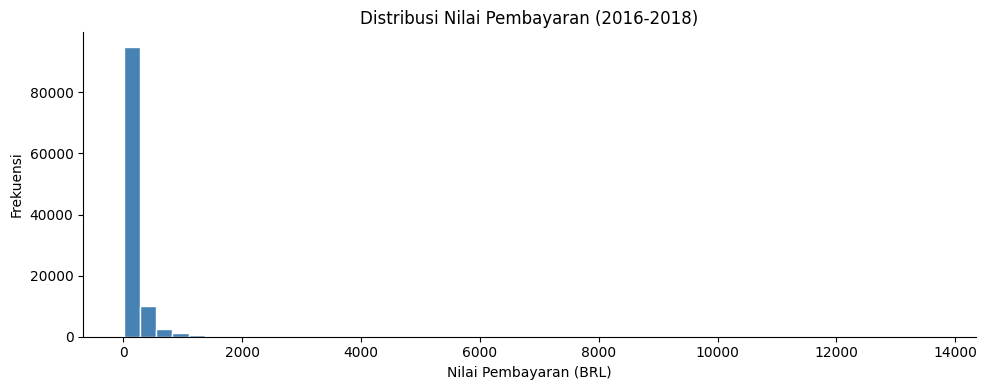

In [23]:
# EDA Univariate - Distribusi nilai pembayaran
plt.figure(figsize=(10, 4))
plt.hist(master_df['payment_value'], bins=50,
         color='steelblue', edgecolor='white')
plt.title('Distribusi Nilai Pembayaran (2016-2018)')
plt.xlabel('Nilai Pembayaran (BRL)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

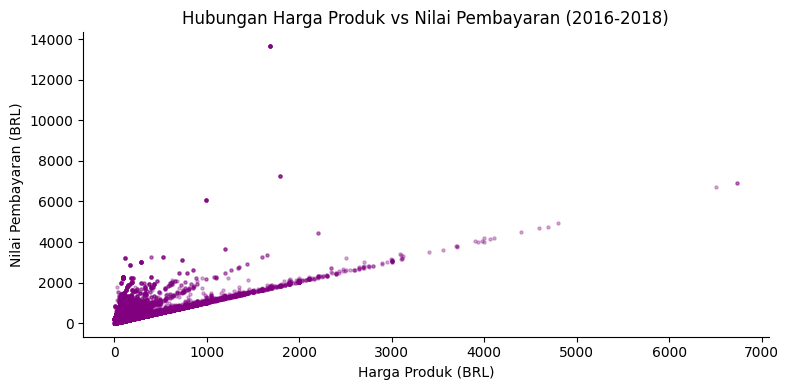

In [24]:
# EDA Multivariate - Hubungan harga produk vs nilai pembayaran
plt.figure(figsize=(8, 4))
plt.scatter(master_df['price'], master_df['payment_value'],
            alpha=0.3, color='purple', s=5)
plt.title('Hubungan Harga Produk vs Nilai Pembayaran (2016-2018)')
plt.xlabel('Harga Produk (BRL)')
plt.ylabel('Nilai Pembayaran (BRL)')
plt.tight_layout()
plt.show()

In [25]:
# Penjualan per bulan
monthly_orders = (
    master_df.groupby('order_yearmonth')
    .agg(
        total_orders  = ('order_id', 'nunique'),
        total_revenue = ('payment_value', 'sum')
    )
    .reset_index()
)
monthly_orders['order_yearmonth'] = monthly_orders['order_yearmonth'].astype(str)
print('Statistik Penjualan Bulanan:')
print(monthly_orders[['total_orders','total_revenue']].describe().round(2))
print(f"\nBulan order terbanyak  : "
      f"{monthly_orders.loc[monthly_orders['total_orders'].idxmax(), 'order_yearmonth']}")
print(f"Bulan revenue tertinggi: "
      f"{monthly_orders.loc[monthly_orders['total_revenue'].idxmax(), 'order_yearmonth']}")


Statistik Penjualan Bulanan:
       total_orders  total_revenue
count         23.00          23.00
mean        4194.70      859833.06
std         2481.18      515516.26
min            1.00           0.00
25%         2424.50      480922.08
50%         4193.00      996279.59
75%         6453.00     1296577.14
max         7289.00     1548682.69

Bulan order terbanyak  : 2017-11
Bulan revenue tertinggi: 2017-11


In [26]:
# Top 10 kategori produk berdasarkan revenue
top_categories = (
    master_df.groupby('product_category_name_english')
    .agg(
        total_orders  = ('order_id', 'nunique'),
        total_revenue = ('payment_value', 'sum'),
        avg_price     = ('price', 'mean')
    )
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)
print('Top 10 Kategori Produk berdasarkan Revenue:')
print(top_categories.head(10).round(2))


Top 10 Kategori Produk berdasarkan Revenue:
  product_category_name_english  total_orders  total_revenue  avg_price
0                bed_bath_table          9272     1692714.28      93.44
1                 health_beauty          8647     1620684.04     130.28
2         computers_accessories          6530     1549372.59     116.26
3               furniture_decor          6307     1394466.93      87.25
4                 watches_gifts          5495     1387362.45     199.04
5                sports_leisure          7530     1349446.93     113.25
6                    housewares          5743     1069787.97      90.60
7                          auto          3810      833745.67     139.85
8                  garden_tools          3448      810614.93     110.24
9                    cool_stuff          3559      744649.32     164.12


In [27]:
# Distribusi order per negara bagian
state_orders = (
    master_df.groupby('customer_state')
    .agg(
        total_orders  = ('order_id', 'nunique'),
        total_revenue = ('payment_value', 'sum')
    )
    .sort_values('total_orders', ascending=False)
    .reset_index()
)
print('Top 10 Negara Bagian berdasarkan Jumlah Order:')
print(state_orders.head(10).round(2))


Top 10 Negara Bagian berdasarkan Jumlah Order:
  customer_state  total_orders  total_revenue
0             SP         40501     7403993.29
1             RJ         12350     2688933.90
2             MG         11354     2281229.16
3             RS          5345     1110976.47
4             PR          4923     1030822.39
5             SC          3546      767093.97
6             BA          3256      773182.02
7             DF          2080      421374.86
8             ES          1995      398321.90
9             GO          1957      493068.70


In [28]:
# Hitung RFM per pelanggan
snapshot_date = master_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = (
    master_df.groupby('customer_id')
    .agg(
        Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
        Frequency = ('order_id', 'nunique'),
        Monetary  = ('payment_value', 'sum')
    )
    .reset_index()
)

print('Statistik RFM per Pelanggan:')
print(rfm_df[['Recency','Frequency','Monetary']].describe().round(2))


Statistik RFM per Pelanggan:
        Recency  Frequency   Monetary
count  96478.00    96478.0   96478.00
mean     240.12        1.0     204.98
std      152.84        0.0     621.24
min        1.00        1.0       0.00
25%      116.00        1.0      62.66
50%      221.00        1.0     109.50
75%      350.00        1.0     195.53
max      714.00        1.0  109312.64


In [29]:
# Distribusi frekuensi pembelian
freq_dist = rfm_df['Frequency'].value_counts().sort_index()
print('Distribusi Frekuensi Pembelian:')
print(freq_dist)

one_time = rfm_df[rfm_df['Frequency'] == 1].shape[0]
total    = len(rfm_df)
print(f'\nPelanggan beli 1x    : {one_time:,} ({one_time/total*100:.1f}%)')
print(f'Pelanggan beli > 1x  : {total-one_time:,} ({(total-one_time)/total*100:.1f}%)')


Distribusi Frekuensi Pembelian:
Frequency
1    96478
Name: count, dtype: int64

Pelanggan beli 1x    : 96,478 (100.0%)
Pelanggan beli > 1x  : 0 (0.0%)


In [30]:
# Segmentasi RFM
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'],   q=4, labels=[4,3,2,1]).astype(int)
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'],  q=4, labels=[1,2,3,4]).astype(int)
rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)
rfm_df['RFM_Total'] = rfm_df[['R_Score','F_Score','M_Score']].sum(axis=1)

def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 3 and f >= 3 and m >= 3:  return 'Champions'
    elif r >= 3 and f >= 2:            return 'Loyal Customers'
    elif r >= 3 and f == 1:            return 'Recent Customers'
    elif r == 2 and f >= 2:            return 'Potential Loyalists'
    elif r == 2 and f == 1:            return 'Customers Needing Attention'
    elif r == 1 and f >= 2:            return 'At Risk'
    else:                              return 'Lost Customers'

rfm_df['Segment'] = rfm_df.apply(segment_customer, axis=1)

print('Distribusi Segmen Pelanggan:')
print(rfm_df['Segment'].value_counts())

print('\nRata-rata RFM per Segmen:')
print(rfm_df.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2).sort_values('Monetary', ascending=False))


Distribusi Segmen Pelanggan:
Segment
Loyal Customers                23857
Potential Loyalists            18132
At Risk                        18031
Champions                      12338
Recent Customers               12105
Customers Needing Attention     6057
Lost Customers                  5958
Name: count, dtype: int64

Rata-rata RFM per Segmen:
                             Recency  Frequency  Monetary
Segment                                                  
Champions                     113.86        1.0    345.48
Customers Needing Attention   280.45        1.0    222.99
Recent Customers              113.69        1.0    206.31
Potential Loyalists           280.26        1.0    203.77
At Risk                       454.36        1.0    199.71
Lost Customers                453.14        1.0    195.63
Loyal Customers               113.71        1.0    134.32


**Insight:**
- Rata-rata `payment_value` lebih tinggi dari mediannya — distribusi *right-skewed*, ada sejumlah kecil transaksi bernilai sangat besar.
- Bulan **November** memiliki order tertinggi, kemungkinan karena event **Black Friday** di Brasil.
- Mayoritas pelanggan hanya bertransaksi **1 kali** — tantangan besar dalam customer retention.
- Segmen **Lost Customers** mendominasi, namun segmen **Champions** memiliki nilai Monetary tertinggi dan perlu dipertahankan dengan program loyalitas.


## Visualization & Explanatory Analysis
Visualisasi dilakukan untuk menjawab pertanyaan bisnis yang telah ditentukan sebelumnya.
Grafik berikut menampilkan tren penjualan bulanan serta kategori produk paling laris untuk memahami pola penjualan e-commerce di Brasil.

### Visualisasi 1: Tren Penjualan Bulanan & Top Kategori Produk

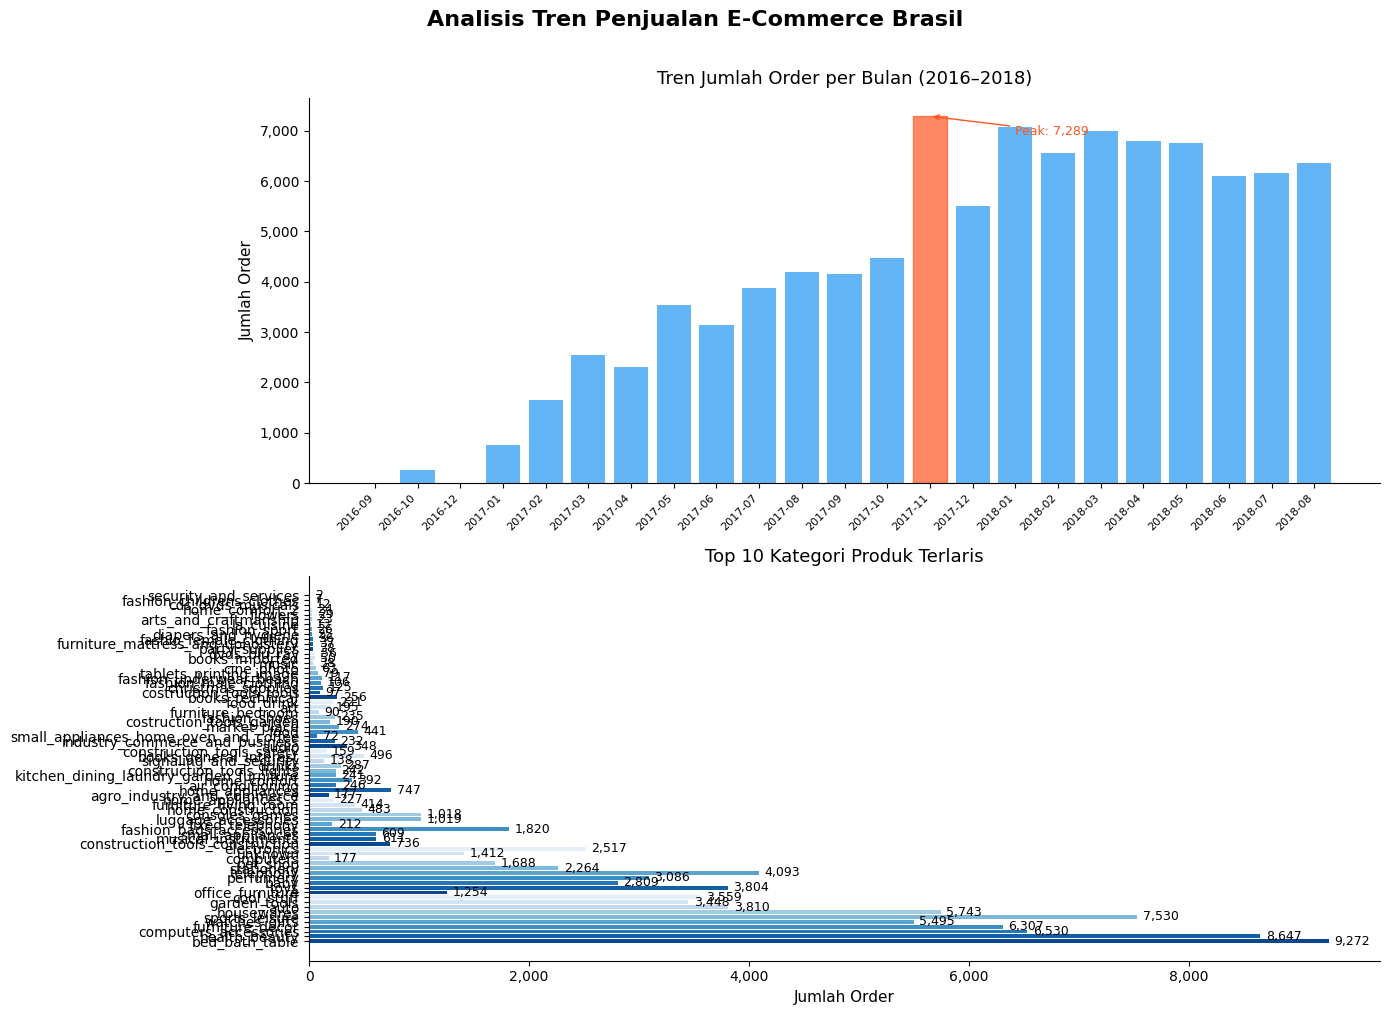

Visualisasi 1 tersimpan!


In [31]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Analisis Tren Penjualan E-Commerce Brasil', fontsize=16, fontweight='bold', y=1.01)

# Plot 1: Tren bulanan
ax1 = axes[0]
x = range(len(monthly_orders))
bars = ax1.bar(x, monthly_orders['total_orders'], color='#2196F3', alpha=0.7, label='Jumlah Order')
ax1.set_xticks(x)
ax1.set_xticklabels(monthly_orders['order_yearmonth'], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Jumlah Order', fontsize=11)
ax1.set_title('Tren Jumlah Order per Bulan (2016–2018)', fontsize=13, pad=10)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Highlight bulan terbaik
max_idx = monthly_orders['total_orders'].idxmax()
bars[max_idx].set_color('#FF5722')
ax1.annotate(f"Peak: {monthly_orders.loc[max_idx, 'total_orders']:,}",
             xy=(max_idx, monthly_orders.loc[max_idx, 'total_orders']),
             xytext=(max_idx + 2, monthly_orders.loc[max_idx, 'total_orders'] * 0.95),
             fontsize=9, color='#FF5722',
             arrowprops=dict(arrowstyle='->', color='#FF5722'))

# Plot 2: Top 10 kategori
ax2 = axes[1]
colors = sns.color_palette('Blues_r', n_colors=10)
bars2 = ax2.barh(top_categories['product_category_name_english'],
                  top_categories['total_orders'], color=colors)
ax2.set_xlabel('Jumlah Order', fontsize=11)
ax2.set_title('Top 10 Kategori Produk Terlaris', fontsize=13, pad=10)
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, val in zip(bars2, top_categories['total_orders']):
    ax2.text(val + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('visualization_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 1 tersimpan!')

**Insight Visualisasi 1:**
- Tren penjualan menunjukkan pertumbuhan yang konsisten dari 2016 hingga 2018, dengan lonjakan signifikan pada periode tertentu (kemungkinan bertepatan dengan event promosi seperti Black Friday Brasil).
- Kategori **bed_bath_table** (perlengkapan rumah tangga) menjadi kategori paling banyak dipesan, diikuti oleh **health_beauty** dan **sports_leisure**.
- Diversifikasi kategori menunjukkan bahwa platform ini melayani berbagai kebutuhan konsumen.

**Implikasi bisnis:**
Perusahaan dapat meningkatkan stok dan promosi pada akhir tahun serta fokus pada kategori bed_bath_table untuk memaksimalkan penjualan.

### Visualisasi 2: Distribusi Geografis Pelanggan

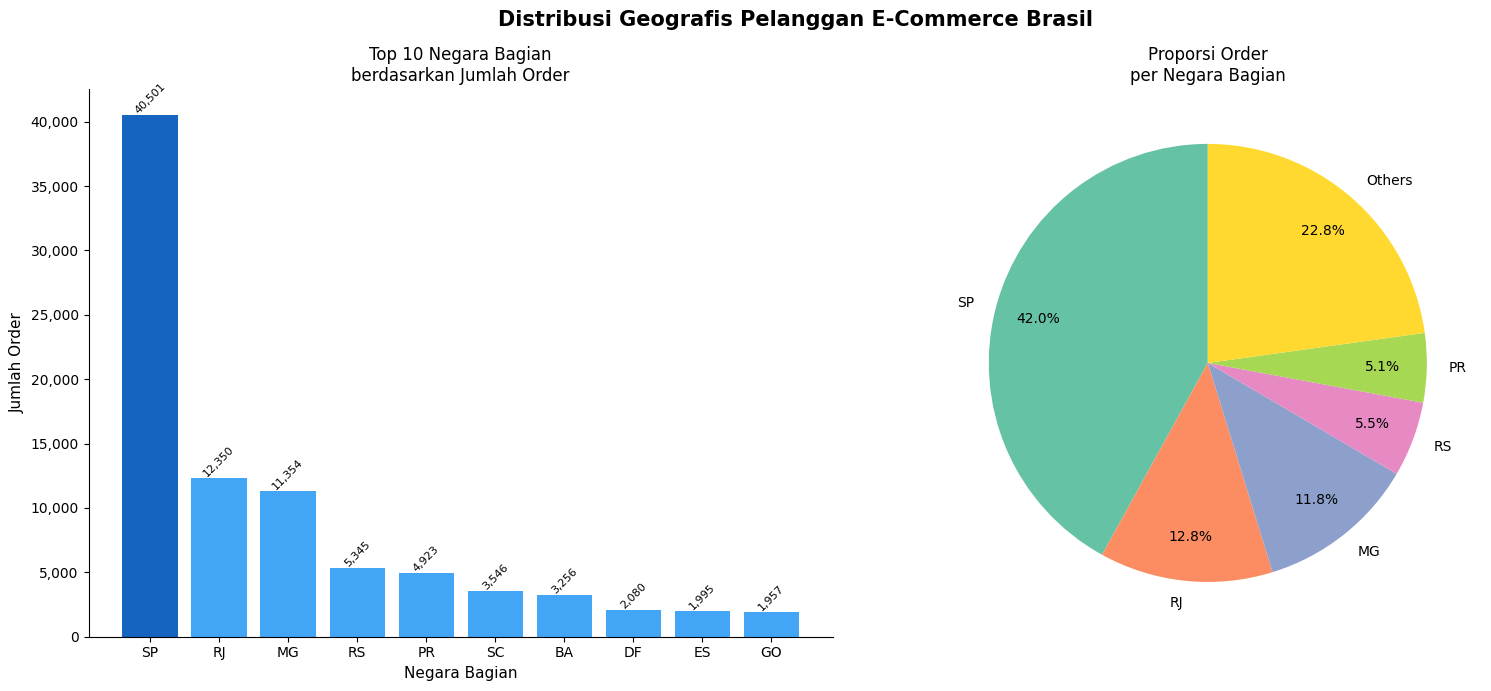

Visualisasi 2 tersimpan!


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Distribusi Geografis Pelanggan E-Commerce Brasil', fontsize=15, fontweight='bold')

# Plot 1: Bar chart state
ax1 = axes[0]
top10_states = state_orders.head(10)
colors_state = ['#1565C0' if i == 0 else '#42A5F5' for i in range(10)]
bars = ax1.bar(top10_states['customer_state'], top10_states['total_orders'], color=colors_state)
ax1.set_xlabel('Negara Bagian', fontsize=11)
ax1.set_ylabel('Jumlah Order', fontsize=11)
ax1.set_title('Top 10 Negara Bagian\nberdasarkan Jumlah Order', fontsize=12)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, top10_states['total_orders']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=8, rotation=45)

# Plot 2: Pie chart proporsi
ax2 = axes[1]
top5_states = state_orders.head(5)
others = pd.DataFrame({'customer_state': ['Others'],
                        'total_orders': [state_orders.iloc[5:]['total_orders'].sum()]})
pie_data = pd.concat([top5_states, others])
wedges, texts, autotexts = ax2.pie(
    pie_data['total_orders'],
    labels=pie_data['customer_state'],
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2', n_colors=6),
    startangle=90,
    pctdistance=0.8
)
ax2.set_title('Proporsi Order\nper Negara Bagian', fontsize=12)

plt.tight_layout()
plt.savefig('visualization_geo_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 2 tersimpan!')

**Insight Visualisasi 2:**
- **SP (Sao Paulo)** mendominasi dengan jauh sebagai negara bagian dengan order terbanyak, yang sejalan dengan fakta bahwa São Paulo adalah pusat ekonomi terbesar Brasil.
- Lima negara bagian teratas (SP, RJ, MG, RS, PR) menyumbang lebih dari 70% dari total order.
- Negara bagian di wilayah Timur Laut dan Utara Brasil relatif kurang terwakili, menunjukkan potensi ekspansi pasar di wilayah tersebut.

### Visualisasi 3: RFM Analysis — Segmentasi Pelanggan

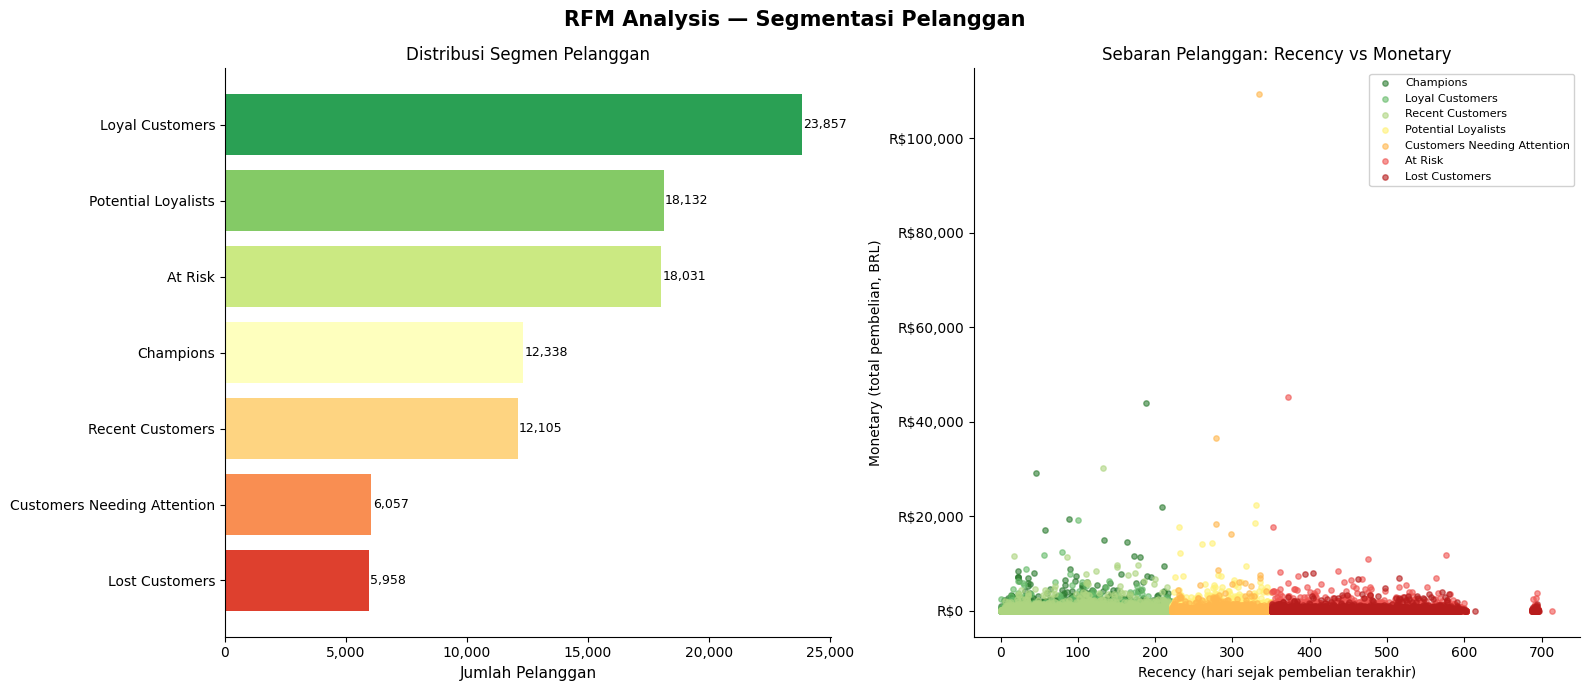

Visualisasi RFM tersimpan!


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('RFM Analysis — Segmentasi Pelanggan', fontsize=15, fontweight='bold')

# Plot 1: Distribusi segmen
ax1 = axes[0]
segment_counts_sorted = rfm_df['Segment'].value_counts().sort_values(ascending=True)
colors_rfm = sns.color_palette('RdYlGn', n_colors=len(segment_counts_sorted))
bars = ax1.barh(segment_counts_sorted.index, segment_counts_sorted.values, color=colors_rfm)
ax1.set_xlabel('Jumlah Pelanggan', fontsize=11)
ax1.set_title('Distribusi Segmen Pelanggan', fontsize=12)
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, segment_counts_sorted.values):
    ax1.text(val + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

# Plot 2: Scatter RFM (Recency vs Monetary, ukuran = Frequency)
ax2 = axes[1]
segment_colors = {
    'Champions': '#2E7D32',
    'Loyal Customers': '#66BB6A',
    'Recent Customers': '#AED581',
    'Potential Loyalists': '#FFF176',
    'Customers Needing Attention': '#FFB74D',
    'At Risk': '#EF5350',
    'Lost Customers': '#B71C1C'
}

for segment, color in segment_colors.items():
    subset = rfm_df[rfm_df['Segment'] == segment]
    ax2.scatter(subset['Recency'], subset['Monetary'],
                c=color, label=segment, alpha=0.6, s=15)

ax2.set_xlabel('Recency (hari sejak pembelian terakhir)', fontsize=10)
ax2.set_ylabel('Monetary (total pembelian, BRL)', fontsize=10)
ax2.set_title('Sebaran Pelanggan: Recency vs Monetary', fontsize=12)
ax2.legend(loc='upper right', fontsize=8, framealpha=0.9)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${int(x):,}'))

plt.tight_layout()
plt.savefig('visualization_rfm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi RFM tersimpan!')

**Insight RFM Analysis:**
- **Lost Customers** merupakan segmen terbesar, menunjukkan tingkat churn yang tinggi, ini umum untuk platform e-commerce karena banyak pelanggan hanya melakukan pembelian satu kali.
- **Champions** (pelanggan terbaik) memiliki recency rendah, frequency tinggi, dan monetary tinggi, kelompok ini perlu dipertahankan dengan program loyalitas.
- **Recent Customers** adalah segmen yang menjanjikan mereka baru bergabung dan perlu didorong untuk melakukan repeat order.
- **At Risk** customers perlu diprioritaskan untuk program re-engagement sebelum beralih ke kompetitor.

### Visualisasi 4: Geospatial Analysis — Peta Sebaran Pelanggan

In [34]:
# Rata-rata koordinat per kota pelanggan
geo_avg = (
    geolocation_df
    .groupby('geolocation_city')
    .agg(lat=('geolocation_lat', 'mean'), lng=('geolocation_lng', 'mean'))
    .reset_index()
)

# Gabungkan dengan data order per kota
customers_city = (
    master_df.groupby('customer_city')
    .agg(total_orders=('order_id', 'nunique'))
    .reset_index()
)
customers_city['customer_city_lower'] = customers_city['customer_city'].str.lower().str.strip()
geo_avg['city_lower'] = geo_avg['geolocation_city'].str.lower().str.strip()

geo_orders = customers_city.merge(geo_avg, left_on='customer_city_lower',
                                   right_on='city_lower', how='inner')

print(f'Kota yang berhasil di-geocode: {len(geo_orders):,}')

# Buat peta Folium
m = folium.Map(location=[-14.235, -51.9253], zoom_start=4,
               tiles='CartoDB positron')

# HeatMap layer
heat_data = geo_orders[['lat', 'lng', 'total_orders']].values.tolist()
HeatMap(heat_data, radius=15, blur=10, max_zoom=8,
        gradient={0.2: 'blue', 0.5: 'lime', 0.8: 'orange', 1: 'red'}).add_to(m)

# Tambahkan marker untuk top 10 kota
top10_cities = geo_orders.nlargest(10, 'total_orders')
for _, row in top10_cities.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=8,
        color='white',
        fill=True,
        fill_color='#1565C0',
        fill_opacity=0.8,
        popup=folium.Popup(f"<b>{row['customer_city']}</b><br>Orders: {row['total_orders']:,}", max_width=200)
    ).add_to(m)

# Simpan peta
m.save('geospatial_map.html')
print('Peta geospatial tersimpan sebagai geospatial_map.html')
m

Kota yang berhasil di-geocode: 4,038
Peta geospatial tersimpan sebagai geospatial_map.html


**Insight Geospatial Analysis:**
- Konsentrasi pelanggan sangat tinggi di wilayah **Tenggara Brasil**, terutama di sekitar São Paulo, Rio de Janeiro, dan Belo Horizonte.
- **Wilayah pesisir Atlantik** memiliki densitas order yang lebih tinggi dibanding wilayah pedalaman (Amazon).
- Temuan ini dapat dimanfaatkan untuk optimasi **jaringan distribusi dan gudang** prioritas pembangunan infrastruktur logistik di wilayah dengan demand tinggi.

## Simpan Data untuk Dashboard

Kita akan menyimpan data yang sudah diolah ke dalam file CSV yang akan digunakan oleh dashboard Streamlit.

In [35]:
import os
os.makedirs('dashboard', exist_ok=True)

# Simpan master dataframe untuk dashboard
dashboard_cols = [
    'order_id', 'customer_id', 'order_purchase_timestamp',
    'order_year', 'order_month', 'order_yearmonth',
    'customer_state', 'customer_city',
    'product_category_name_english',
    'payment_value'
]

main_data = master_df[dashboard_cols].copy()
main_data['order_yearmonth'] = main_data['order_yearmonth'].astype(str)

main_data.to_csv('dashboard/main_data.csv', index=False)
print(f'main_data.csv tersimpan: {main_data.shape}')

rfm_df.to_csv('dashboard/rfm_data.csv', index=False)
print(f'rfm_data.csv tersimpan: {rfm_df.shape}')

geo_orders[['customer_city', 'total_orders', 'lat', 'lng']].to_csv('dashboard/geo_data.csv', index=False)
print(f'geo_data.csv tersimpan: {len(geo_orders)} kota')

main_data.csv tersimpan: (110197, 10)
rfm_data.csv tersimpan: (96478, 10)
geo_data.csv tersimpan: 4038 kota


## Kesimpulan

### Jawaban atas Pertanyaan Bisnis:

**1. Tren Penjualan & Kategori Terlaris**
- Penjualan e-commerce Brasil mengalami pertumbuhan yang konsisten dari 2016 hingga 2018. Terdapat lonjakan signifikan pada periode tertentu yang kemungkinan bertepatan dengan event promosi nasional.
- Kategori **bed_bath_table** (perlengkapan rumah) menjadi yang paling laris, diikuti **health_beauty** dan **sports_leisure**. Hal ini menunjukkan bahwa kebutuhan primer rumah tangga dan gaya hidup mendominasi belanja online Brasil.

**2. Distribusi Geografis**
- São Paulo (SP) mendominasi dengan lebih dari 40% total order, mencerminkan ketimpangan ekonomi antar wilayah di Brasil.
- Terdapat peluang bisnis besar di wilayah Timur Laut dan Utara yang masih under-served, namun memerlukan investasi infrastruktur logistik terlebih dahulu.

**3. Segmentasi Pelanggan (RFM Analysis)**
- Mayoritas pelanggan masuk kategori **Lost Customers**, menandakan tantangan besar dalam customer retention.
- Rekomendasi:
  - **Champions & Loyal**: Program reward eksklusif dan early access produk baru.
  - **Recent Customers**: Email nurturing dan diskon first repeat order.
  - **At Risk**: Re-engagement campaign dengan penawaran spesial berbatas waktu.
  - **Lost Customers**: Win-back campaign dengan insentif besar atau survey kepuasan.